In [1]:
# First, install the missing library
!pip install timm
!pip install transformers datasets evaluate torch torchvision pillow

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
from datasets import Dataset, Image
from torchvision import transforms
import timm
from sklearn.metrics import classification_report, confusion_matrix 
from pathlib import Path
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import random

In [2]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("kavyasreeb/hair-type-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sho0o\.cache\kagglehub\datasets\kavyasreeb\hair-type-dataset\versions\1


In [3]:
data_path = Path(r"C:\Users\sho0o\.cache\kagglehub\datasets\kavyasreeb\hair-type-dataset\versions\1\data")

file_names = []
labels = []

for file in tqdm(sorted(data_path.glob("*/*.*"))):
    file_names.append(str(file))
    label = str(file).split(os.sep)[-2].lower()
    labels.append(label)

print(len(file_names), len(labels), len(set(labels)))

df = pd.DataFrame.from_dict({"image": file_names, "label": labels})
df.head()

100%|██████████████████████████████████████████████████████████████████████████| 1992/1992 [00:00<00:00, 360022.99it/s]

1992 1992 5


,image,label
0,C:\Users\sho0o\.cache\kagglehub\datasets\kavya...,curly
1,C:\Users\sho0o\.cache\kagglehub\datasets\kavya...,curly
2,C:\Users\sho0o\.cache\kagglehub\datasets\kavya...,curly
3,C:\Users\sho0o\.cache\kagglehub\datasets\kavya...,curly
4,C:\Users\sho0o\.cache\kagglehub\datasets\kavya...,curly


In [4]:
# تحويل df إلى Dataset
dataset = Dataset.from_pandas(df)

# تحويل عمود الصور من "نص مسار" إلى "صورة فعلية"
dataset = dataset.cast_column("image", Image())

dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 1992
})

In [5]:
# Create a dataset from a Pandas DataFrame.
dataset = Dataset.from_pandas(df).cast_column("image", Image())

In [6]:
dataset[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=614x768>,
 'label': 'curly'}

In [7]:
dataset[0]["image"].show()

In [8]:
# نجيب كل الفئات الموجودة
labels_list = sorted(df["label"].unique())
labels_list

['curly', 'dreadlocks', 'kinky', 'straight', 'wavy']

In [9]:
# نحول كل فئة (كلمة) إلى رقم
label2id = {label: idx for idx, label in enumerate(labels_list)}
id2label = {idx: label for label, idx in label2id.items()}

label2id, id2label

({'curly': 0, 'dreadlocks': 1, 'kinky': 2, 'straight': 3, 'wavy': 4},
 {0: 'curly', 1: 'dreadlocks', 2: 'kinky', 3: 'straight', 4: 'wavy'})

In [10]:
# نحول عمود الليبل إلى أرقام بناءً على الخرائط السابقة
dataset = dataset.class_encode_column("label")
dataset

Casting to class labels:   0%|          | 0/1992 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 1992
})

In [11]:
dataset = dataset.train_test_split(
    test_size=0.3,               # 30% اختبار - ممتاز للـ CPU
    stratify_by_column="label"   # يحافظ على توازن الفئات
)

train_data = dataset["train"]
test_data  = dataset["test"]


In [12]:
train_data, test_data

(Dataset({
     features: ['image', 'label'],
     num_rows: 1394
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 598
 }))

In [13]:
image_size = 224

train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),             # تحويل لضمان RGB
    transforms.Resize((image_size, image_size)),                    # توحيد الحجم
    transforms.RandomHorizontalFlip(p=0.5),                         # عكس أفقي أحيانًا
    transforms.RandomRotation(10),                                  # دوران بسيط جدًا
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),  # تعديلات خفيفة فقط
    transforms.ToTensor(),                                          # تحويل لتنسور
    transforms.Normalize([0.5]*3, [0.5]*3),                         # تطبيع
])


val_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [14]:
def apply_train_transforms(batch):
    batch["image"] = [train_transforms(img) for img in batch["image"]]
    return batch

def apply_val_transforms(batch):
    batch["image"] = [val_transforms(img) for img in batch["image"]]
    return batch

train_data = train_data.with_transform(apply_train_transforms)
test_data  = test_data.with_transform(apply_val_transforms)


In [15]:
def collate_fn(batch):
    images = torch.stack([example["image"] for example in batch])
    labels = torch.tensor([example["label"] for example in batch])
    return images, labels

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, collate_fn=collate_fn)

In [16]:
num_classes = len(labels_list)

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=num_classes
)

In [17]:
device = torch.device("cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-5)

In [18]:
# ------------------ Tracking Lists ------------------
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

# ------------------ Best Model + Early Stopping Setup ------------------
best_val_acc = 0.0
best_model_state = None
patience = 5                 # كم Epoch ننتظر قبل الإيقاف
no_improve_count = 0         # عداد عدم التحسن

epochs = 30  # حتى لو كتبته 30، Early Stopping بيوقف قبله لو احتاج

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    # ------------------ Training ------------------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct_train / total_train

    # ------------------ Validation ------------------
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = correct_val / total_val

    # store stats
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ------------------ Best Model + Early Stopping Logic ------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        no_improve_count = 0
        print("Improvement detected! Best model updated.")
    else:
        no_improve_count += 1
        print(f" No improvement for {no_improve_count} epoch(s).")

    if no_improve_count >= patience:
        print("\n Early Stopping triggered! Training stopped early.")
        break

# ------------------ Save Best Model ------------------
torch.save(best_model_state, "best_model.pth")
print("\n Training completed. Best model saved as: best_model.pth")

Epoch 1/30 | Train Loss: 1.9999 | Train Acc: 0.4864 | Val Loss: 1.0018 | Val Acc: 0.6639
Improvement detected! Best model updated.
Epoch 2/30 | Train Loss: 0.6862 | Train Acc: 0.7697 | Val Loss: 0.7399 | Val Acc: 0.7742
Improvement detected! Best model updated.
Epoch 3/30 | Train Loss: 0.4757 | Train Acc: 0.8529 | Val Loss: 0.6741 | Val Acc: 0.7893
Improvement detected! Best model updated.
Epoch 4/30 | Train Loss: 0.3224 | Train Acc: 0.8859 | Val Loss: 0.6199 | Val Acc: 0.7977
Improvement detected! Best model updated.
Epoch 5/30 | Train Loss: 0.2122 | Train Acc: 0.9275 | Val Loss: 0.5722 | Val Acc: 0.8211
Improvement detected! Best model updated.
Epoch 6/30 | Train Loss: 0.2089 | Train Acc: 0.9376 | Val Loss: 0.5597 | Val Acc: 0.8311
Improvement detected! Best model updated.
Epoch 7/30 | Train Loss: 0.1631 | Train Acc: 0.9433 | Val Loss: 0.5841 | Val Acc: 0.8161
 No improvement for 1 epoch(s).
Epoch 8/30 | Train Loss: 0.1405 | Train Acc: 0.9498 | Val Loss: 0.5854 | Val Acc: 0.8227
 No 

In [19]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
print("Best model loaded and ready for inference.")

Best model loaded and ready for inference.


In [20]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=labels_list))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

       curly       0.91      0.81      0.86       154
  dreadlocks       0.94      0.98      0.96       133
       kinky       0.80      0.86      0.83        65
    straight       0.87      0.89      0.88       147
        wavy       0.76      0.78      0.77        99

    accuracy                           0.87       598
   macro avg       0.86      0.87      0.86       598
weighted avg       0.87      0.87      0.87       598

[[125   2  13   2  12]
 [  1 131   0   1   0]
 [  4   4  56   1   0]
 [  1   2   1 131  12]
 [  6   1   0  15  77]]


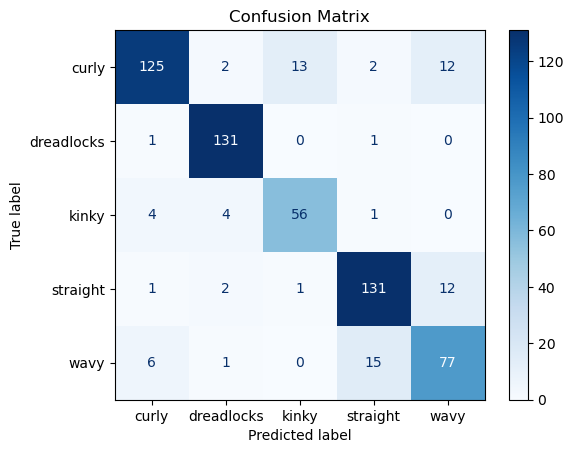

In [21]:
# حطي هذولي بعد ما خلص التدريب وجبتي y_true و y_pred
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# تحميل أفضل موديل تم حفظه في Stage-1
model.load_state_dict(torch.load("best_model.pth"))

# فك تجميد آخر 30-40 طبقة فقط من EfficientNet-B0
for name, param in model.named_parameters():
    if "blocks.6" in name or "conv_head" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# خفض الـ Learning Rate
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

epochs = 10  # تدريب قصير لأن هذا Fine-Tuning

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)

    print(f"Fine-Tune Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {train_acc:.4f}")

# حفظ الموديل النهائي
torch.save(model.state_dict(), "best_model_finetuned.pth")
print("\n Fine-Tuning Done. Model saved as best_model_finetuned.pth")


Fine-Tune Epoch 1/10 | Loss: 0.0429 | Acc: 0.9864
Fine-Tune Epoch 2/10 | Loss: 0.0308 | Acc: 0.9900
Fine-Tune Epoch 3/10 | Loss: 0.0235 | Acc: 0.9928
Fine-Tune Epoch 4/10 | Loss: 0.0407 | Acc: 0.9900
Fine-Tune Epoch 5/10 | Loss: 0.0267 | Acc: 0.9935
Fine-Tune Epoch 6/10 | Loss: 0.0286 | Acc: 0.9914
Fine-Tune Epoch 7/10 | Loss: 0.0398 | Acc: 0.9900
Fine-Tune Epoch 8/10 | Loss: 0.0446 | Acc: 0.9857
Fine-Tune Epoch 9/10 | Loss: 0.0435 | Acc: 0.9900
Fine-Tune Epoch 10/10 | Loss: 0.0335 | Acc: 0.9907

 Fine-Tuning Done. Model saved as best_model_finetuned.pth


In [23]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=labels_list))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

       curly       0.90      0.84      0.87       154
  dreadlocks       0.94      0.98      0.96       133
       kinky       0.82      0.85      0.83        65
    straight       0.87      0.93      0.90       147
        wavy       0.81      0.75      0.78        99

    accuracy                           0.88       598
   macro avg       0.87      0.87      0.87       598
weighted avg       0.88      0.88      0.88       598

[[130   1  10   2  11]
 [  2 130   0   1   0]
 [  5   4  55   1   0]
 [  1   3   1 136   6]
 [  7   1   1  16  74]]


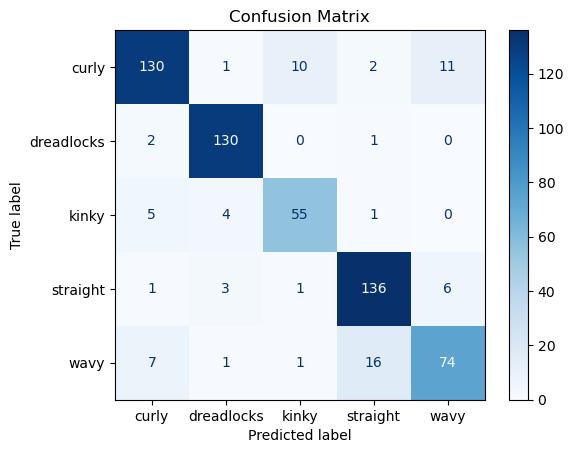

In [24]:
# حطي هذولي بعد ما خلص التدريب وجبتي y_true و y_pred
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


In [25]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

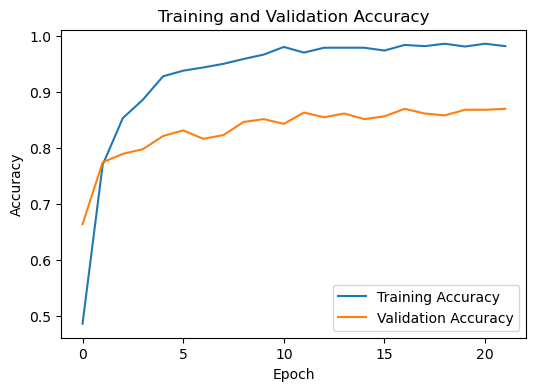

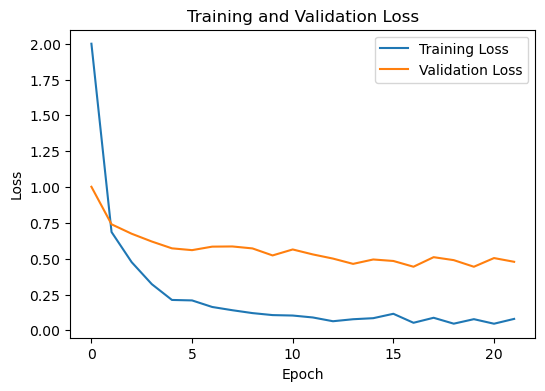

In [26]:
plt.figure(figsize=(6,4))
plt.plot(train_acc_list, label="Training Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_loss_list, label="Training Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


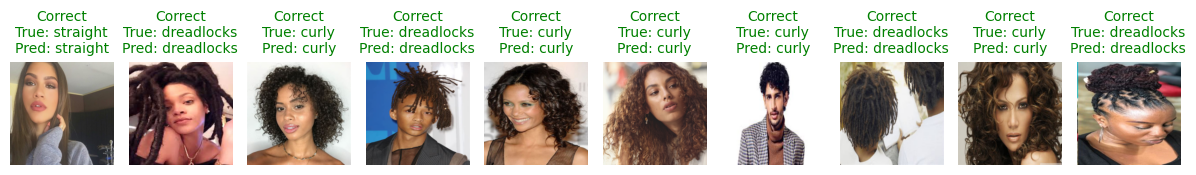

In [31]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np

# دالة لإرجاع الصورة لطبيعتها بعد Normalize
def denormalize(img_tensor):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    return img

# عرض صور عشوائية من بيانات الاختبار + التنبؤات
def show_predictions(model, dataset, device, n=10):
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices, 1):
        sample = dataset[idx]
        image = sample["image"]
        label = sample["label"]

        # تجهيز الصورة للنموذج
        inp = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(inp)
            pred = torch.argmax(output, dim=1).item()

        # مقارنة التوقع بالصح
        true_name = id2label[label]
        pred_name = id2label[pred]
        color = "green" if pred_name == true_name else "red"
        status = "Correct" if pred_name == true_name else " Wrong"

        # عرض الصورة
        plt.subplot(1, n, i)
        plt.imshow(denormalize(image))
        plt.axis("off")
        plt.title(f"{status}\nTrue: {true_name}\nPred: {pred_name}", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

# نادِ الدالة:
show_predictions(model, test_data, device, n=10)

